# <span style='color:Red'>Figure fixer</span>

## <span style='color:Red'>Libraries, functions, paths</span>

In [1]:
import sys, os
from pathlib import Path

currentWD = os.path.dirname(Path.cwd())
if currentWD not in sys.path:
    sys.path.append(currentWD)
#print(sys.path)

import numpy, os, pandas, re, ast, seaborn, jlib
from matplotlib import pyplot
from matplotlib import patches

saveFigs = True
imagePath = 'img/final/'
imageFormats = ['svg','pdf']
exportsPath = 'exports/'

significanceSize = 14

desiredEffectSize = 'ges'

paletteBase = {'Chunkable':'#a1c9f4','Non-chunkable':'#ffb482'}

coloursPath = '../../experiment3_EEG/StimResponse/Exp3_ColorSpace_6.csv'
colourCircleValues = numpy.genfromtxt(coloursPath,delimiter=',')

colourCircleValues = colourCircleValues[::int(colourCircleValues.shape[0]/360)]
colourCircleValues = (colourCircleValues+1)*0.5

if not os.path.exists(imagePath):
    os.makedirs(imagePath)

mapValueHandler = jlib.data.mapValueHandler.MapValueHandler(exportsPath+"exp3Values.csv")

allParticipantData = pandas.read_csv(exportsPath+'participantData_long_preEEG.csv')
allParticipantData.drop(['Mouse X path','Mouse Y path'],axis=1,inplace=True)

## <span style='color:Red'>Figure 2</span>

R[write to console]: In addition: 
R[write to console]: Warning message:

R[write to console]: package 'jmv' was built under R version 4.4.3 



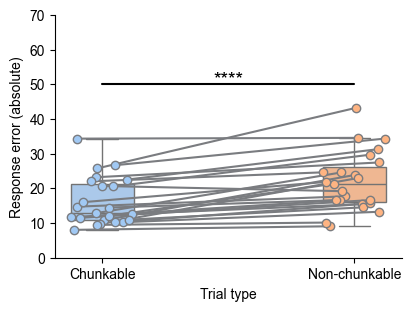

In [2]:
minAccuracyValue = 0
maxAccuracyValue = 1.2

minErrorOverBlocksValue = 0
maxErrorOverBlocksValue = 70

minBaseErrorOverBlocksValue = -20
maxBaseErrorOverBlocksValue = 20

absErrData = allParticipantData.copy()
absErrData = absErrData.groupby(['Subject','Trial type']).median().reset_index()

absErrNCTrial = absErrData.loc[absErrData['Trial type']=='Non-chunkable',:]['Response error (absolute)'].to_numpy()
absErrCTrial = absErrData.loc[absErrData['Trial type']=='Chunkable',:]['Response error (absolute)'].to_numpy()

absErrChunkingTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                             column1=absErrNCTrial,
                                                             column2=absErrCTrial,
                                                             isStudent=True,isWilcoxon=False,hypothesis='oneGreater',
                                                             effectSize=True,descriptives=True)

absErrChunkingTtestPS['ttest'].columns = absErrChunkingTtestPS['ttest'].columns.str.rstrip('[stud]')

fig,ax = pyplot.subplots(figsize=(4,3),constrained_layout=True)
seaborn.set_style('ticks')
seaborn.despine()

# Ax1,1: effect of chunking over absolute error
jlib.display.pairedObs.boxPlotPaired(ax=ax,
                                     data=absErrData,
                                     x='Trial type',y='Response error (absolute)',
                                     width=0.25,palette=paletteBase)
ax.set_ylim(minErrorOverBlocksValue,maxErrorOverBlocksValue)
jlib.display.utils.displayPairwiseSignificance(ax,[0,1],50*numpy.array([1,1]),size=significanceSize,
                                               p=absErrChunkingTtestPS['ttest']['p'].to_numpy()[0])

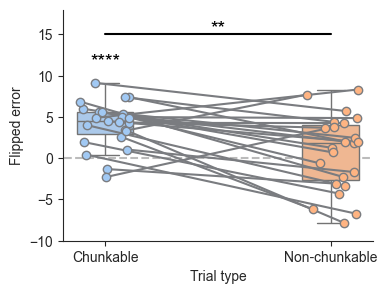

In [3]:
minBiasValue = -10
maxBiasValue = 18

minBiasDistValue = -10
maxBiasDistValue = 10

minSlopeValue = -1
maxSlopeValue = 1

columnsToKeep = ['Subject','Trial type','Response error','Flipped error']

copyData = allParticipantData.copy()
copyData.drop([column for column in copyData.columns if column not in columnsToKeep],axis=1,inplace=True)

angleColumns = [column for column in copyData.columns if column not in ['Subject','Trial type','Cue type']]
meanData = copyData.groupby(['Subject','Trial type'])[angleColumns].apply(
    lambda x: pandas.Series({col: jlib.analysis.circularStats.circularMean(x[col].to_numpy()) for col in angleColumns})).reset_index()
meanData

meanNCTrialData = meanData[meanData['Trial type']=='Non-chunkable']['Flipped error'].to_numpy()
meanCTrialData = meanData[meanData['Trial type']=='Chunkable']['Flipped error'].to_numpy()

baseBiasTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                       column1=meanCTrialData,column2=meanNCTrialData,
                                                       isStudent=True,isWilcoxon=False,hypothesis='different',
                                                       effectSize=True,descriptives=True)

baseBiasTtestPS['ttest'].columns = baseBiasTtestPS['ttest'].columns.str.rstrip('[stud]')

baseBiasTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                       variables=[meanCTrialData,meanNCTrialData],
                                                       testValue=0,isStudent=True,isWilcoxon=False,hypothesis='gt',
                                                       effectSize=True,descriptives=True)

baseBiasTtestOS['ttest'].columns = baseBiasTtestOS['ttest'].columns.str.rstrip('[stud]')

baseBiasTtestOS

fig,ax = pyplot.subplots(figsize=(4,3))
ax.plot([-0.28,1.28],[0,0],'--',color='#bbbbbb')
jlib.display.pairedObs.boxPlotPaired(ax=ax,
                                     data=meanData,
                                     x='Trial type',y='Flipped error',
                                     width=0.25,palette=paletteBase)
ax.set_xlim(-0.1875,1.1875)
ax.set_ylim(minBiasValue,maxBiasValue)
seaborn.despine()
jlib.display.utils.displayPairwiseSignificance(ax,[0,1],15*numpy.array([1,1]),size=significanceSize,
                                               p=baseBiasTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax,0,11,size=significanceSize,
                                               p=2*baseBiasTtestOS['ttest']['p'].to_numpy()[0])

Text(1.02, 0.4642857142857143, 'Attraction')

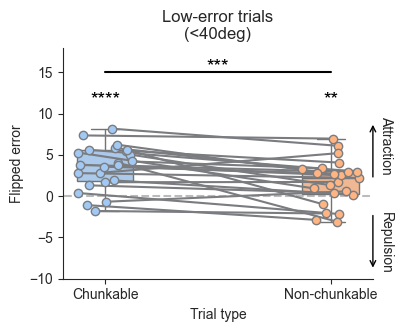

In [4]:
copyGoodData = copyData.copy()
copyGoodData = copyGoodData[numpy.abs(copyGoodData['Response error'])<=40]

meanGoodData = copyGoodData.groupby(['Subject','Trial type'])[angleColumns].apply(
    lambda x: pandas.Series({col: jlib.analysis.circularStats.circularMean(x[col].to_numpy()) for col in angleColumns})).reset_index()

biasGoodNCTrialData = meanGoodData[meanGoodData['Trial type']=='Non-chunkable']['Flipped error'].to_numpy()
biasGoodCTrialData = meanGoodData[meanGoodData['Trial type']=='Chunkable']['Flipped error'].to_numpy()

goodBiasTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                       column1=biasGoodCTrialData,
                                                       column2=biasGoodNCTrialData,
                                                       isStudent=True,isWilcoxon=False,hypothesis='different',
                                                       effectSize=True,descriptives=True)

goodBiasTtestPS['ttest'].columns = goodBiasTtestPS['ttest'].columns.str.rstrip('[stud]')

goodBiasTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                       variables=[biasGoodCTrialData,biasGoodNCTrialData],
                                                       testValue=0,isStudent=True,isWilcoxon=False,hypothesis='gt',
                                                       effectSize=True,descriptives=True)

goodBiasTtestOS['ttest'].columns = goodBiasTtestOS['ttest'].columns.str.rstrip('[stud]')

fig,ax = pyplot.subplots(figsize=(4,3))
ax.plot([-0.28,1.28],[0,0],'--',color='#bbbbbb')
jlib.display.pairedObs.boxPlotPaired(ax=ax,
                                     data=meanGoodData,
                                     x='Trial type',y='Flipped error',
                                     width=0.25,palette=paletteBase)
seaborn.despine()
ax.set_xlim(-0.1875,1.1875)
ax.set_ylim(minBiasValue,maxBiasValue)
ax.set_title('Low-error trials\n(<40deg)')
jlib.display.utils.displayPairwiseSignificance(ax,[0,1],15*numpy.array([1,1]),size=significanceSize,
                                               p=goodBiasTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax,0,11,size=significanceSize,
                                               p=2*goodBiasTtestOS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax,1,11,size=significanceSize,
                                               p=2*goodBiasTtestOS['ttest']['p'].to_numpy()[1])
ax.annotate('',xy=(1,1/28),xytext=(1,8/28),xycoords='axes fraction',textcoords='axes fraction',
                 ha='center',va='bottom',rotation=90,arrowprops=dict(arrowstyle='->',lw=1,color='black'))
ax.annotate('Repulsion',xy=(0,0),xytext=(1.02,1/28),textcoords='axes fraction',rotation=-90)
ax.annotate('',xy=(1,19/28),xytext=(1,12/28),xycoords='axes fraction',textcoords='axes fraction',
                 ha='center',va='bottom',rotation=90,arrowprops=dict(arrowstyle='->',lw=1,color='black'))
ax.annotate('Attraction',xy=(0,0),xytext=(1.02,13/28),textcoords='axes fraction',rotation=-90)

C:\Users\juanm\AppData\Local\Temp\ipykernel_46904\2409823059.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['{a:.0f}'.format(a=float(tick.get_text())) for tick in ax.get_xticklabels()])


(-10.0, 10.0)

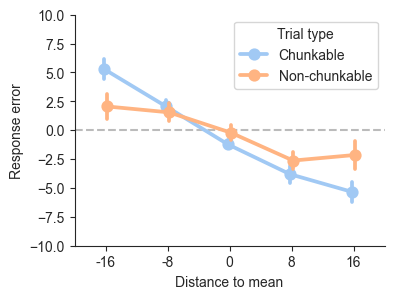

In [5]:
distCopyData = allParticipantData.copy()
nTargets = numpy.unique(distCopyData['Target']).shape[0]

distCopyData['Distance to mean'] = distCopyData.apply(
    lambda x: jlib.compression.experimentValues.splitByDistanceToMean(x,5,
                                                                      jlib.compression.constants.EXP3_OFFSET_ANGLE,
                                                                      nTargets,
                                                                      jlib.compression.constants.EXP3_RESPONSE_SECTIONS,
                                                                      expType='Exp3'),axis=1)

distGoodCopyData = distCopyData.copy()
distGoodCopyData = distGoodCopyData[numpy.abs(distGoodCopyData['Response error'])<=40]

angleColumns = [column for column in distGoodCopyData.columns if column not in ['Subject','Trial type','Cue type','Distance to mean']]
distGoodMeanData = distGoodCopyData.groupby(['Subject','Trial type','Distance to mean'])[angleColumns].apply(
    lambda x: pandas.Series({col: jlib.analysis.circularStats.circularMean(x[col].to_numpy()) for col in angleColumns})).reset_index()

fig,ax = pyplot.subplots(figsize=(4,3))
ax.plot([-0.5,4.5],[0,0],'--',color='#bbbbbb')
seaborn.pointplot(ax=ax,
                  data=distGoodMeanData,
                  x='Distance to mean',y='Response error',hue='Trial type',
                  errorbar='se',dodge=True,estimator=numpy.nanmean,palette=paletteBase)
seaborn.despine()
ax.set_xticklabels(['{a:.0f}'.format(a=float(tick.get_text())) for tick in ax.get_xticklabels()])
ax.set_xlim(-0.5,4.5)
ax.set_ylim(minBiasDistValue,maxBiasDistValue)

Text(1.02, 0.55, 'Repulsion')

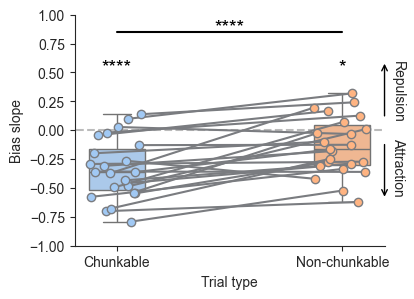

In [6]:
columnsToKeep = ['Subject','Trial type','Response error','True target']

distGoodModelData = allParticipantData.copy()
distGoodModelData = distGoodModelData[numpy.abs(distGoodModelData['Response error'])<=40]
distGoodModelData['True target'] = (distGoodModelData['Continuous target']-distGoodModelData['Mean target'])/3
distGoodModelData.drop([column for column in distGoodModelData.columns if column not in columnsToKeep],axis=1,inplace=True)

allFitsC = []
allFitsNC = []

optimizationBounds = (numpy.array([-numpy.inf,-numpy.inf]),numpy.array([numpy.inf,numpy.inf]))

for participant in numpy.unique(distGoodModelData['Subject']):
    participantModelData = distGoodModelData[distGoodModelData['Subject']==participant]
    # print('Fitting data for participant',participant)
    # Fit chunkable trials
    xC = participantModelData[participantModelData['Trial type']=='Chunkable']['True target'].to_numpy()
    yC = participantModelData[participantModelData['Trial type']=='Chunkable']['Response error'].to_numpy()
    fitStartingPointC = [0,numpy.mean(yC)]
    fitC = jlib.analysis.models.fitLine(xC,yC,fitStartingPointC,optimizationBounds)
    allFitsC.append(fitC.x)
    # Fit non-chunkable trials
    xNC = participantModelData[participantModelData['Trial type']=='Non-chunkable']['True target'].to_numpy()
    yNC = participantModelData[participantModelData['Trial type']=='Non-chunkable']['Response error'].to_numpy()
    fitStartingPointNC = [0,numpy.mean(yNC)]
    fitNC = jlib.analysis.models.fitLine(xNC,yNC,fitStartingPointNC,optimizationBounds)
    allFitsNC.append(fitNC.x)

allFitsC = numpy.array(allFitsC)
allFitsNC = numpy.array(allFitsNC)

biasSlopesNCTrial = allFitsNC[:,0]
biasSlopesCTrial = allFitsC[:,0]

biasSlopeTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                        column1=biasSlopesNCTrial,column2=biasSlopesCTrial,
                                                        isStudent=True,isWilcoxon=False,hypothesis='different',
                                                        effectSize=True,descriptives=True)

biasSlopeTtestPS['ttest'].columns = biasSlopeTtestPS['ttest'].columns.str.rstrip('[stud]')

biasSlopeTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                        variables=[biasSlopesCTrial,biasSlopesNCTrial],
                                                        testValue=0,isStudent=True,isWilcoxon=False,hypothesis='lt',
                                                        effectSize=True,descriptives=True)

biasSlopeTtestOS['ttest'].columns = biasSlopeTtestOS['ttest'].columns.str.rstrip('[stud]')

a = numpy.unique(meanData['Subject'])
b = numpy.array(['Chunkable','Non-chunkable'])
slopeDF = pandas.DataFrame.from_dict({'Subject':numpy.tile(a,b.size),
                                      'Trial type':numpy.repeat(b, a.size),
                                      'Bias slope':numpy.concatenate((biasSlopesCTrial,biasSlopesNCTrial),axis=0)})

fig,ax = pyplot.subplots(figsize=(4,3))
ax.plot([-0.28,1.28],[0,0],'--',color='#bbbbbb')
jlib.display.pairedObs.boxPlotPaired(ax=ax,
                                     data=slopeDF,
                                     x='Trial type',y='Bias slope',
                                     width=0.25,palette=paletteBase)
seaborn.despine()
ax.set_xlim(-0.1875,1.1875)
ax.set_ylim(minSlopeValue,maxSlopeValue)
jlib.display.utils.displayPairwiseSignificance(ax,[0,1],0.85*numpy.array([1,1]),size=significanceSize,
                                               p=biasSlopeTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax,0,0.5,size=significanceSize,
                                               p=2*biasSlopeTtestOS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax,1,0.5,size=significanceSize,
                                               p=2*biasSlopeTtestOS['ttest']['p'].to_numpy()[1])
ax.annotate('',xy=(1,0.2),xytext=(1,0.45),xycoords='axes fraction',textcoords='axes fraction',
                 ha='center',va='bottom',rotation=90,arrowprops=dict(arrowstyle='->',lw=1,color='black'))
ax.annotate('Attraction',xy=(0,0),xytext=(1.02,0.23),textcoords='axes fraction',rotation=-90)
ax.annotate('',xy=(1,0.8),xytext=(1,0.55),xycoords='axes fraction',textcoords='axes fraction',
                 ha='center',va='bottom',rotation=90,arrowprops=dict(arrowstyle='->',lw=1,color='black'))
ax.annotate('Repulsion',xy=(0,0),xytext=(1.02,0.55),textcoords='axes fraction',rotation=-90)

C:\Users\juanm\AppData\Local\Temp\ipykernel_46904\3022236525.py:42: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  seaborn.lineplot(ax=ax,data=distPlotData,x='Error to mean',y='Percent',hue='Distance to mean',legend=False,


(-60.0, 60.0)

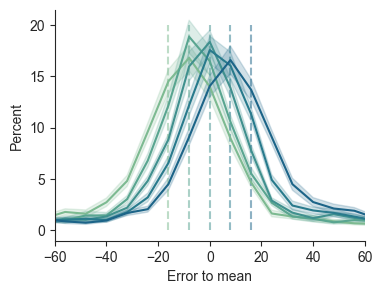

In [7]:
distFinalData = allParticipantData.copy()
distFinalData['Distance to mean'] = distFinalData.apply(
    lambda x: jlib.compression.experimentValues.splitByDistanceToMean(x,5,
                                                                      jlib.compression.constants.EXP3_OFFSET_ANGLE,
                                                                      numpy.unique(distFinalData['Target']).shape[0],
                                                                      jlib.compression.constants.EXP3_RESPONSE_SECTIONS,
                                                                      expType='Exp3'),axis=1)

distFinalData['Response'] = distFinalData['Continuous target']*360/jlib.compression.constants.EXP3_RESPONSE_SECTIONS+distFinalData['Response error']
distPlotData = {'Subject':numpy.array([]),'Distance to mean':numpy.array([]),
                'Percent':numpy.array([]),'Error to mean':numpy.array([])}

distFinalData['Error to mean'] = -distFinalData['Mean target']*360/jlib.compression.constants.EXP3_RESPONSE_SECTIONS+distFinalData['Response']
distFinalData['Error to mean'] = distFinalData.apply(
    lambda x: numpy.arctan2(numpy.sin(x['Error to mean']*numpy.pi/180),
                            numpy.cos(x['Error to mean']*numpy.pi/180))*180/numpy.pi,axis=1)

# distFinalData.loc[distFinalData['Distance to mean']==16,'Error to mean'] *= -1 
# distFinalData.loc[distFinalData['Distance to mean']==16,'Distance to mean'] = -16
# distFinalData.loc[distFinalData['Distance to mean']==8,'Error to mean'] *= -1
# distFinalData.loc[distFinalData['Distance to mean']==8,'Distance to mean'] = -8

fig,ax = pyplot.subplots(figsize=(4,3))
i = 0
for dist in numpy.unique(distFinalData['Distance to mean']):
    dataDist = distFinalData.copy()
    dataDist.drop(dataDist[dataDist['Distance to mean']!=dist].index,inplace=True)
    for participant in numpy.unique(dataDist['Subject']):
        participantData = dataDist.loc[(dataDist['Trial type']=='Chunkable') &
                                       (dataDist['Subject']==participant),'Error to mean'].copy()
        hist,binEdges = numpy.histogram(participantData,bins=45,range=(-180,180),
                                        weights=numpy.ones(participantData.shape[0],)*1/participantData.shape[0])
        binCenters = (binEdges[:-1]+binEdges[1:])/2
        distPlotData['Subject'] = numpy.concatenate((distPlotData['Subject'],numpy.ones(binCenters.shape[0],)*participant))
        distPlotData['Percent'] = numpy.concatenate((distPlotData['Percent'],hist*100))
        distPlotData['Error to mean'] = numpy.concatenate((distPlotData['Error to mean'],binCenters))
        distPlotData['Distance to mean'] = numpy.concatenate((distPlotData['Distance to mean'],
                                                              numpy.ones(binCenters.shape[0],)*dist))
    ax.plot([dist,dist],[0,20],'--',alpha=0.5,color=seaborn.color_palette("crest")[i])
    i += 1
distPlotDF = pandas.DataFrame.from_dict(distPlotData)
seaborn.lineplot(ax=ax,data=distPlotData,x='Error to mean',y='Percent',hue='Distance to mean',legend=False,
                 errorbar='se',palette=seaborn.color_palette("crest"))
seaborn.despine()
ax.set_xlim(-60,60)

C:\Users\juanm\AppData\Local\Temp\ipykernel_46904\2306513323.py:35: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  seaborn.lineplot(ax=ax['B'],data=distPlotData,x='Error to mean',y='Percent',hue='Distance to mean',legend=True,


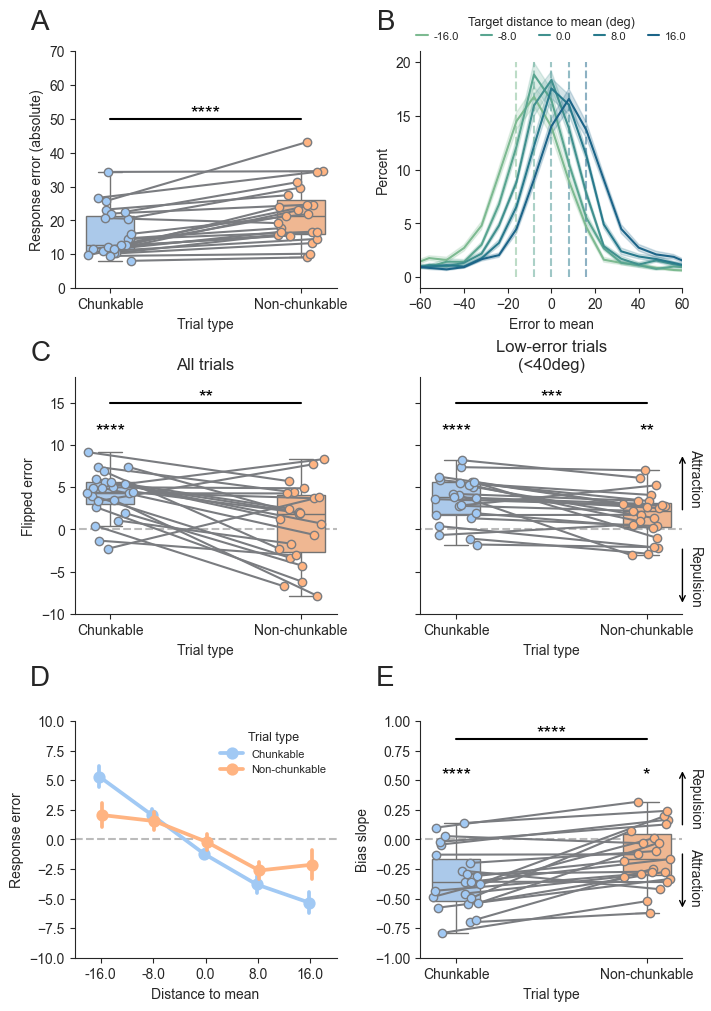

In [8]:
# Create the figure
# fig,ax = pyplot.subplot_mosaic([['A','A'],['B','B'],['C','D'],['E','F']],figsize=(7,12),constrained_layout=True)
fig,ax = pyplot.subplot_mosaic([['A','B'],['C','D'],['E','F']],figsize=(7,10),constrained_layout=True)
seaborn.set_style('ticks')

# AxA: effect of chunking over absolute error
jlib.display.pairedObs.boxPlotPaired(ax=ax['A'],
                                     data=absErrData,
                                     x='Trial type',y='Response error (absolute)',
                                     width=0.25,palette=paletteBase)
ax['A'].set_ylim(minErrorOverBlocksValue,maxErrorOverBlocksValue)
ax['A'].text(-0.42,76.5,'A',fontsize=20)
jlib.display.utils.displayPairwiseSignificance(ax['A'],[0,1],50*numpy.array([1,1]),size=significanceSize,
                                               p=absErrChunkingTtestPS['ttest']['p'].to_numpy()[0])

# AxB: existence of a bias
i = 0
for dist in numpy.unique(distFinalData['Distance to mean']):
    dataDist = distFinalData.copy()
    dataDist.drop(dataDist[dataDist['Distance to mean']!=dist].index,inplace=True)
    for participant in numpy.unique(dataDist['Subject']):
        participantData = dataDist.loc[(dataDist['Trial type']=='Chunkable') &
                                       (dataDist['Subject']==participant),'Error to mean'].copy()
        hist,binEdges = numpy.histogram(participantData,bins=45,range=(-180,180),
                                        weights=numpy.ones(participantData.shape[0],)*1/participantData.shape[0])
        binCenters = (binEdges[:-1]+binEdges[1:])/2
        distPlotData['Subject'] = numpy.concatenate((distPlotData['Subject'],numpy.ones(binCenters.shape[0],)*participant))
        distPlotData['Percent'] = numpy.concatenate((distPlotData['Percent'],hist*100))
        distPlotData['Error to mean'] = numpy.concatenate((distPlotData['Error to mean'],binCenters))
        distPlotData['Distance to mean'] = numpy.concatenate((distPlotData['Distance to mean'],
                                                              numpy.ones(binCenters.shape[0],)*dist))
    ax['B'].plot([dist,dist],[0,20],'--',alpha=0.5,color=seaborn.color_palette("crest")[i])
    i += 1
distPlotDF = pandas.DataFrame.from_dict(distPlotData)
seaborn.lineplot(ax=ax['B'],data=distPlotData,x='Error to mean',y='Percent',hue='Distance to mean',legend=True,
                 errorbar='se',palette=seaborn.color_palette("crest"))
ax['B'].set_xlim(-60,60)
seaborn.move_legend(
    ax['B'], "lower center",
    bbox_to_anchor=(.5, 1),ncol=5,title='Target distance to mean (deg)',
    fontsize=8,
    title_fontsize=9,
    markerscale=0.7,
    handlelength=1,
    handletextpad=0.5,
    labelspacing=0.3,
    frameon=False,
)
ax['B'].text(-80,23,'B',fontsize=20)

# AxC: bias for all trials
ax['C'].plot([-0.28,1.28],[0,0],'--',color='#bbbbbb')
jlib.display.pairedObs.boxPlotPaired(ax=ax['C'],
                                     data=meanData,
                                     x='Trial type',y='Flipped error',
                                     width=0.25,palette=paletteBase)
ax['C'].set_xlim(-0.1875,1.1875)
ax['C'].set_ylim(minBiasValue,maxBiasValue)
ax['C'].text(-0.42,20,'C',fontsize=20)
ax['C'].set_title('All trials')
jlib.display.utils.displayPairwiseSignificance(ax['C'],[0,1],15*numpy.array([1,1]),size=significanceSize,
                                               p=baseBiasTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax['C'],0,11,size=significanceSize,
                                               p=2*baseBiasTtestOS['ttest']['p'].to_numpy()[0])

# AxD: bias for low-error trials
ax['D'].plot([-0.28,1.28],[0,0],'--',color='#bbbbbb')
jlib.display.pairedObs.boxPlotPaired(ax=ax['D'],
                                     data=meanGoodData,
                                     x='Trial type',y='Flipped error',
                                     width=0.25,palette=paletteBase)
ax['D'].set_xlim(-0.1875,1.1875)
ax['D'].set_ylim(minBiasValue,maxBiasValue)
ax['D'].set_ylabel("")
ax['D'].set_yticklabels("")
ax['D'].set_title('Low-error trials\n(<40deg)')
jlib.display.utils.displayPairwiseSignificance(ax['D'],[0,1],15*numpy.array([1,1]),size=significanceSize,
                                               p=goodBiasTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax['D'],0,11,size=significanceSize,
                                               p=2*goodBiasTtestOS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax['D'],1,11,size=significanceSize,
                                               p=2*goodBiasTtestOS['ttest']['p'].to_numpy()[1])
ax['D'].annotate('',xy=(1,1/28),xytext=(1,8/28),xycoords='axes fraction',textcoords='axes fraction',
                 ha='center',va='bottom',rotation=90,arrowprops=dict(arrowstyle='->',lw=1,color='black'))
ax['D'].annotate('Repulsion',xy=(0,0),xytext=(1.02,1/28),textcoords='axes fraction',rotation=-90)
ax['D'].annotate('',xy=(1,19/28),xytext=(1,12/28),xycoords='axes fraction',textcoords='axes fraction',
                 ha='center',va='bottom',rotation=90,arrowprops=dict(arrowstyle='->',lw=1,color='black'))
ax['D'].annotate('Attraction',xy=(0,0),xytext=(1.02,13/28),textcoords='axes fraction',rotation=-90)

# AxE: bias as a function of distance to mean
ax['E'].plot([-0.5,4.5],[0,0],'--',color='#bbbbbb')
seaborn.pointplot(ax=ax['E'],
                  data=distGoodMeanData,
                  x='Distance to mean',y='Response error',hue='Trial type',
                  errorbar='se',dodge=True,legend=True,estimator=numpy.nanmean,
                  palette=paletteBase)
ax['E'].set_xlim(-0.5,4.5)
ax['E'].set_ylim(minBiasDistValue,maxBiasDistValue)
ax['E'].text(-1.35,13,'D',fontsize=20)
ax['E'].legend(title='Trial type',frameon=False,fontsize=8,title_fontsize=9)

# AxF: bias slopes
ax['F'].plot([-0.28,1.28],[0,0],'--',color='#bbbbbb')
jlib.display.pairedObs.boxPlotPaired(ax=ax['F'],
                                     data=slopeDF,
                                     x='Trial type',y='Bias slope',
                                     width=0.25,palette=paletteBase)
ax['F'].set_xlim(-0.1875,1.1875)
ax['F'].set_ylim(minSlopeValue,maxSlopeValue)
ax['F'].text(-0.42,1.3,'E',fontsize=20)
jlib.display.utils.displayPairwiseSignificance(ax['F'],[0,1],0.85*numpy.array([1,1]),size=significanceSize,
                                               p=biasSlopeTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax['F'],0,0.5,size=significanceSize,
                                               p=2*biasSlopeTtestOS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax['F'],1,0.5,size=significanceSize,
                                               p=2*biasSlopeTtestOS['ttest']['p'].to_numpy()[1])
ax['F'].annotate('',xy=(1,0.2),xytext=(1,0.45),xycoords='axes fraction',textcoords='axes fraction',
                 ha='center',va='bottom',rotation=90,arrowprops=dict(arrowstyle='->',lw=1,color='black'))
ax['F'].annotate('Attraction',xy=(0,0),xytext=(1.02,0.23),textcoords='axes fraction',rotation=-90)
ax['F'].annotate('',xy=(1,0.8),xytext=(1,0.55),xycoords='axes fraction',textcoords='axes fraction',
                 ha='center',va='bottom',rotation=90,arrowprops=dict(arrowstyle='->',lw=1,color='black'))
ax['F'].annotate('Repulsion',xy=(0,0),xytext=(1.02,0.55),textcoords='axes fraction',rotation=-90)

seaborn.despine()

if (saveFigs):
    for format in imageFormats:
        fig.savefig(imagePath+'exp3BehavBias.'+format,format=format,dpi=1200)

C:\Users\juanm\AppData\Local\Temp\ipykernel_46904\2806138950.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(),size=15)


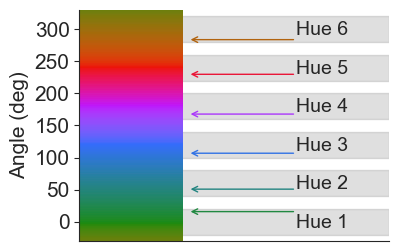

In [9]:
coloursPath = '../../experiment3_EEG/StimResponse/Exp3_ColorSpace_6.csv'
colourCircleValues = numpy.genfromtxt(coloursPath,delimiter=',')

colourCircleValues = colourCircleValues[::int(colourCircleValues.shape[0]/360)]
colourCircleValues = (colourCircleValues+1)*0.5

numpy.random.seed(1)

fig,ax = pyplot.subplots(figsize=(4,3))

# Ax0: average response distribution (non-locked)
forbiddenValues = numpy.array([(20,40),(80,100),(140,160),(200,220),(260,280),(320,340),(380,400)])-60
forbiddenValues = numpy.array([(40,80),(100,140),(160,200),(220,260),(280,320),(340,380)])-60
colorCounter = 0
for ymin,ymax in forbiddenValues:
    ax.axhspan(ymin,ymax,color="grey",alpha=0.25,zorder=0,label=None)
    yValue = numpy.random.randint(ymin,ymax)
    # print(colourCircleValues[yValue%len(colourCircleValues)])
    ax.annotate('',xy=(0.35,yValue/360+0.08),xytext=(0.7,yValue/360+0.08),xycoords='axes fraction',textcoords='axes fraction',
                 ha='center',va='bottom',rotation=90,arrowprops=dict(arrowstyle='->',lw=1,color=colourCircleValues[yValue%len(colourCircleValues)]))
    yMidPoint = 0.5*(ymin+ymax)
    ax.annotate(f'Hue {colorCounter+1}',xy=(0.35,yMidPoint/360+0.08),xytext=(0.7,yMidPoint/360+0.08),
                size=14,xycoords='axes fraction',textcoords='axes fraction',ha='left',va='center')
    colorCounter += 1
for i in range(-100,len(colourCircleValues)):
    ax.add_patch(patches.Rectangle((0,i),0.1,2,linewidth=0,facecolor=colourCircleValues[i%len(colourCircleValues)]))
ax.set_xlim(0,0.3)
ax.set_xticks([])
ax.set_xticklabels("")
ax.set_ylim(-30,330)
ax.set_ylabel("Angle (deg)",size=15)
ax.set_yticklabels(ax.get_yticklabels(),size=15)

seaborn.despine()

if (saveFigs):
    for format in imageFormats:
        fig.savefig(imagePath+'hueSelection.'+format,format=format,dpi=1200)